# 🔧 02 — Feature Engineering
## Building the Customer Feature Matrix

Transforms transaction-level data into a single row per customer with ~25 features:
- **RFM** (Recency, Frequency, Monetary)
- **Purchase Behavior** (AOV, category diversity, discount usage, return rate)
- **Trends** (spending/frequency changes over 90-day windows)
- **Engagement** (proxy scores from purchase activity)

---

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
import config

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Transformed Data

In [2]:
customers = pd.read_csv(os.path.join(config.DATA_RAW, 'customers.csv'))
transactions = pd.read_csv(os.path.join(config.DATA_RAW, 'transactions.csv'))
engagement = pd.read_csv(os.path.join(config.DATA_RAW, 'engagement.csv'))

print(f"Customers: {customers.shape}")
print(f"Transactions: {transactions.shape}")
print(f"Engagement: {engagement.shape}")

Customers: (96096, 8)
Transactions: (111741, 13)
Engagement: (96096, 9)


## 2. Run Feature Engineering Pipeline

In [3]:
from src import feature_engineering

customer_features = feature_engineering.run(
    customers=customers,
    transactions=transactions,
    engagement=engagement
)

print(f"\nFinal shape: {customer_features.shape}")
print(f"Columns: {list(customer_features.columns)}")


PHASE 2: Feature Engineering
  Computing RFM features...
  Computing purchase behavior features...
  Computing trend features...
  Computing engagement score...
  Assembling customer feature matrix...

  ✓ Customer features: 96,096 rows, 34 columns → d:\Customer Profitability and Retention Analytics\data\processed\customer_features.csv

Final shape: (96096, 34)
Columns: ['customer_id', 'age', 'gender', 'region', 'signup_date', 'acquisition_channel', 'customer_tenure_days', 'frequency', 'monetary', 'recency_days', 'avg_order_value', 'median_order_value', 'purchase_std', 'avg_quantity', 'categories_purchased', 'category_concentration', 'discount_usage_rate', 'avg_discount_pct', 'return_rate', 'interpurchase_time_avg', 'interpurchase_time_std', 'super_categories_purchased', 'spending_trend', 'frequency_trend', 'aov_trend', 'engagement_score', 'emails_opened_30d', 'website_visits_30d', 'campaign_clicks_30d', 'app_sessions_30d', 'support_tickets', 'loyalty_program', 'avg_review_score', 're

## 3. Feature Distributions

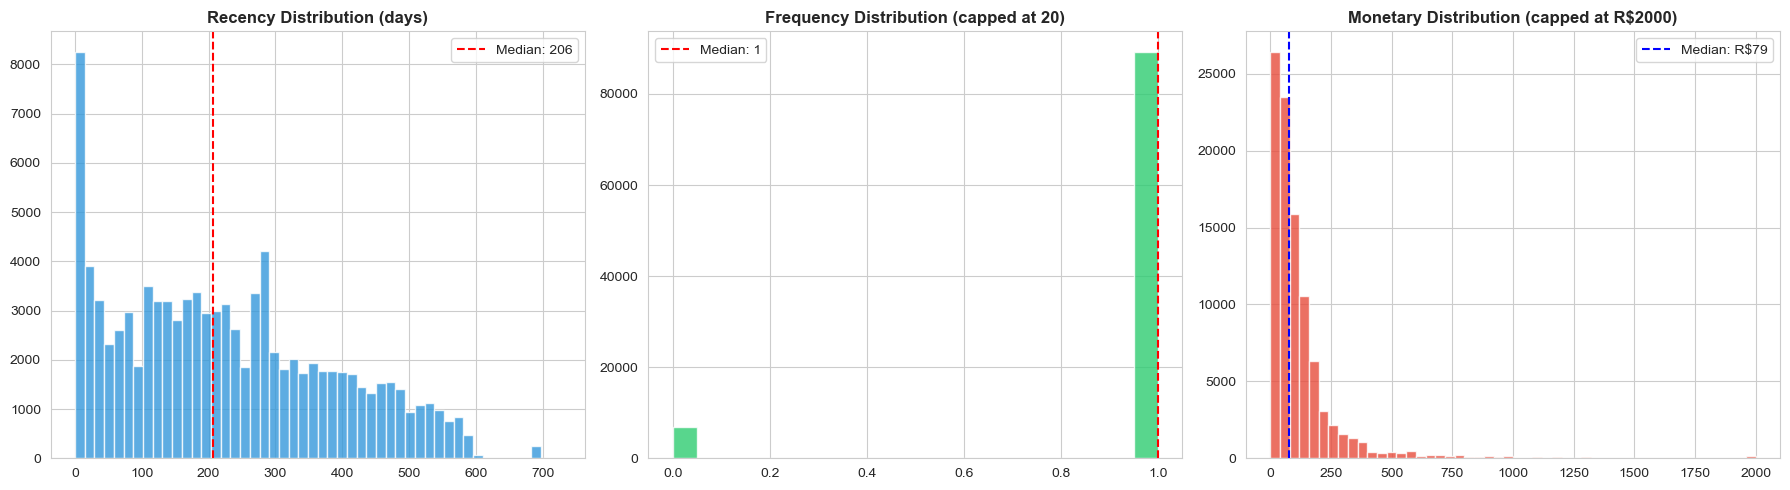

In [4]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(customer_features['recency_days'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Recency Distribution (days)', fontweight='bold')
axes[0].axvline(customer_features['recency_days'].median(), color='red', linestyle='--', label=f"Median: {customer_features['recency_days'].median():.0f}")
axes[0].legend()

axes[1].hist(customer_features['frequency'].clip(0, 20), bins=20, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('Frequency Distribution (capped at 20)', fontweight='bold')
axes[1].axvline(customer_features['frequency'].median(), color='red', linestyle='--', label=f"Median: {customer_features['frequency'].median():.0f}")
axes[1].legend()

axes[2].hist(customer_features['monetary'].clip(0, 2000), bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Monetary Distribution (capped at {config.CURRENCY_SYMBOL}2000)', fontweight='bold')
axes[2].axvline(customer_features['monetary'].median(), color='blue', linestyle='--', label=f"Median: {config.CURRENCY_SYMBOL}{customer_features['monetary'].median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Feature Correlation Heatmap

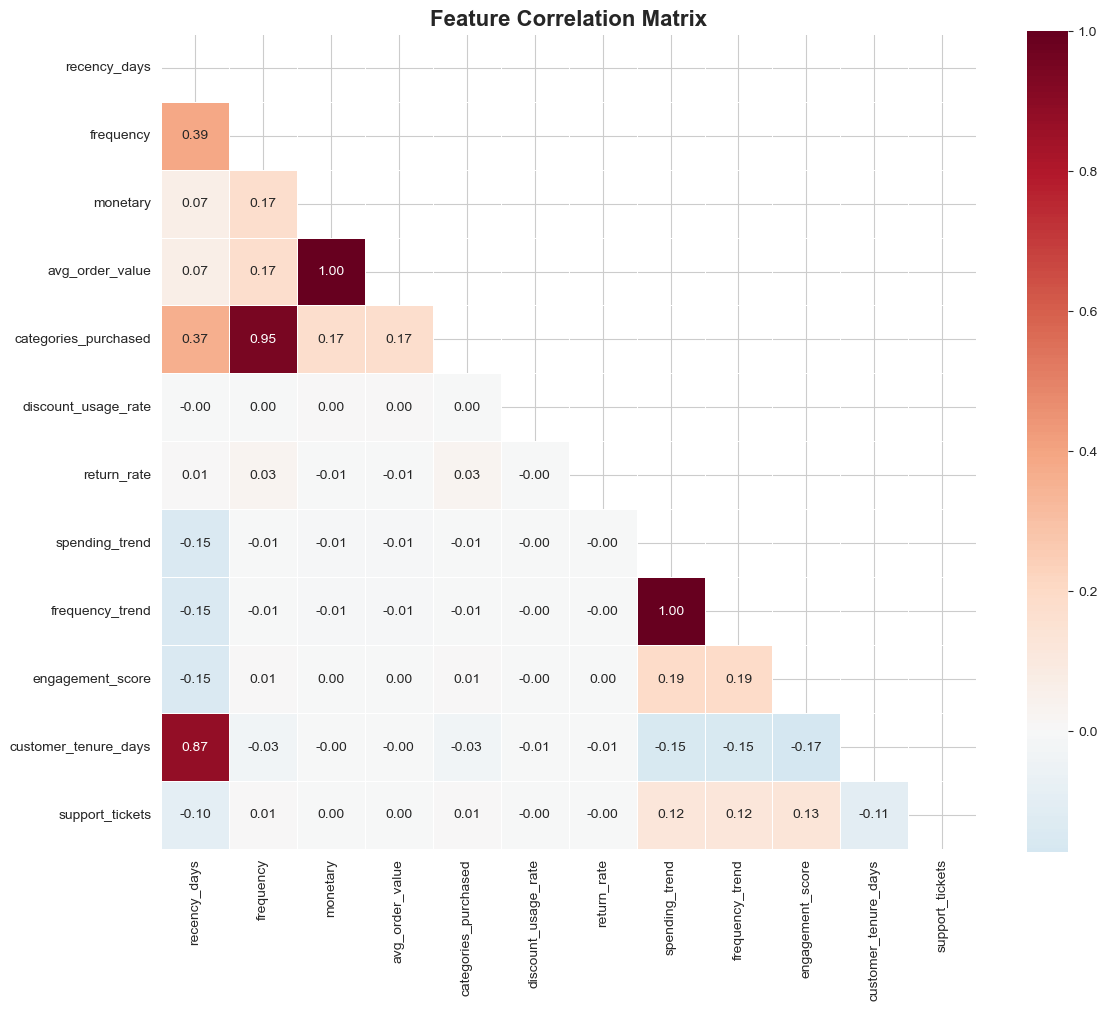

In [5]:
numeric_cols = customer_features.select_dtypes(include=[np.number]).columns
# Select key features for correlation
key_features = ['recency_days', 'frequency', 'monetary', 'avg_order_value',
                 'categories_purchased', 'discount_usage_rate', 'return_rate',
                 'spending_trend', 'frequency_trend', 'engagement_score',
                 'customer_tenure_days', 'support_tickets']
key_features = [c for c in key_features if c in customer_features.columns]

corr = customer_features[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Descriptive Statistics

In [6]:
customer_features[key_features].describe().round(2)

,recency_days,frequency,monetary,avg_order_value,categories_purchased,discount_usage_rate,return_rate,spending_trend,frequency_trend,engagement_score,customer_tenure_days,support_tickets
count,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00,96096.00
mean,225.03,0.93,127.21,127.21,0.94,0.00,0.01,-0.02,-0.02,28.48,242.49,0.01
std,160.11,0.26,204.79,204.79,0.27,0.01,0.05,0.61,0.61,6.91,153.62,0.08
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00,-1.00,4.12,-47.00,0.00
25%,92.00,1.00,37.99,37.99,1.00,0.00,0.00,0.00,0.00,23.66,118.00,0.00
50%,206.00,1.00,79.00,79.00,1.00,0.00,0.00,0.00,0.00,27.86,224.00,0.00
75%,338.00,1.00,144.90,144.90,1.00,0.00,0.00,0.00,0.00,32.61,352.00,0.00
max,727.00,1.00,13440.00,13440.00,3.00,1.00,0.67,1.00,1.00,67.99,726.00,3.00


---
**✅ Feature engineering complete!** Proceed to `03_segmentation.ipynb`.